In [13]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import mne
from scipy.optimize import minimize
from scipy.stats import norm, skewnorm
from math import ceil
import pandas as pd
from sklearn.linear_model import LogisticRegression


repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Upload data

In [2]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)

models_dict, trajectories_dict, binarized_audibilities_dict = {}, {}, {}
    
for part in tqdm(range(20)):

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        trajectories_dict[part] = state_train
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # sort audibilities according to SNR
    sorted_audibilities = {cat: [] for cat in categories}
    binarized_audibilities = {cat: [] for cat in categories}
    for cat in categories:
        cat_indices = np.where(snr == (cat + 1))[0]
        sorted_audibilities[cat] = audibility[cat_indices]
        binarized_audibilities[cat] = (sorted_audibilities[cat] >= 2).astype(int)
    binarized_audibilities_dict[part] = binarized_audibilities

    # load model parameters 
    model = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path + f"/GainModulatedModel_part{part}_params"
    model.load_params(param_path)
    models_dict[part] = model

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_402332/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_402332/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_402332/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_402332/831752060.py:14: RuntimeWarning: 

In [79]:
def metastability_score_point(f, df, x_grid, tau):
    distance_to_critical = f(x_grid)**2 + df(x_grid)**2
    normalized_distance = distance_to_critical * tau**2 # between 0 (critical) and 1 (linear dynamics)
    return x_grid[np.argmin(normalized_distance)], 1-np.min(normalized_distance) 


def find_metapoint(gainmodul, n_categories):

    tau, process_noise, measure_noise, threshold = gainmodul.tau, gainmodul.process_noise, gainmodul.measure_noise, gainmodul.threshold

    states = np.linspace(-0.5, 3, 1000)
    delta_x_list = []
    max_metascore, best_metapoint = 0, None
    
    for cat in range(n_categories - 1):
        # Initial state diff
        delta_x_list.append(gainmodul.core(state=states, input_value=1, signal_category=cat) - states)

        w1, g1 = getattr(gainmodul, f'w{cat}'), getattr(gainmodul, f'g{cat}')
        w2, g2 = getattr(gainmodul, f'w{cat+1}'), getattr(gainmodul, f'g{cat+1}')

        # Travel on the (w1, g1) -> (w2, g2) segment 
        for t in np.linspace(0, 1, 100):
            w, g = w1 + t*(w2-w1), g1 + t*(g2-g1)
            
            interp_model = lead.model.GainModulation(
                tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                threshold=threshold, sharpness=5, 
                input_weight=w, gain=g
            )

            # Prepare for metastability score calculation
            model_func = interp_model.core
            def f(states, input_value=0, signal_category=cat):
                return model_func(states, input_value * np.ones_like(states), signal_category) - states
            def df(states, input_value=0, signal_category=cat):
                epsilon = 1e-5
                return (f(states + epsilon, input_value, signal_category) - f(states - epsilon, input_value, signal_category)) / (2*epsilon)

            # Compute metastability score
            metapoint, metascore = metastability_score_point(lambda x: f(x, input_value=1, signal_category=cat), 
                                            lambda x: df(x, input_value=1, signal_category=cat), 
                                            states, tau=tau)
            if metascore > max_metascore:
                max_metascore = metascore
                best_metapoint = metapoint

    return best_metapoint, max_metascore

Participant 13: Metapoint = 0.7297, Metascore = 1.0000
Participant 13: Threshold = 0.4807 (intercet = -0.4295, coef = 0.8935)


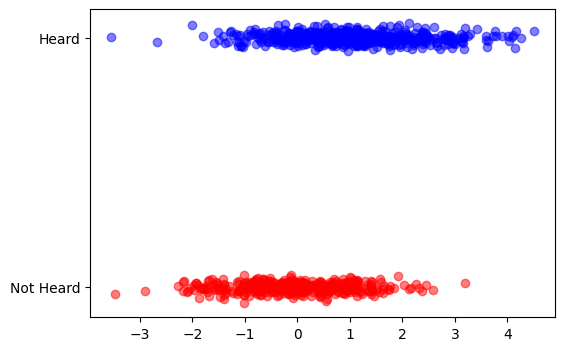

In [80]:
# a function that takes the states at index idx and returns the X, Y arrays of individual trial value at idx and binary audibility
def get_trial_data_at_time(time_idx, state_train, binaud):
    X, Y = [], []
    for cat in state_train.keys():
        for trial_idx, trial in enumerate(state_train[cat]):
            X.append(np.mean(trial[time_idx]))  # take a small window around idx to average
            Y.append(binaud[cat][trial_idx])
    return np.array(X), np.array(Y)



# plot an example of heard, not-heard rainplot for a single participant
part = 13

# find critical point
metapoint, metascore = find_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
print(f"Participant {part}: Metapoint = {metapoint:.4f}, Metascore = {metascore:.4f}")

# use logistic regression to find the threshold for heard vs not-heard from X and Y
X, Y = get_trial_data_at_time(100, trajectories_dict[part], binarized_audibilities_dict[part])
log_reg = LogisticRegression(class_weight='balanced', penalty=None)
log_reg.fit(X.reshape(-1, 1), Y)
threshold = - log_reg.intercept_[0] / log_reg.coef_[0][0]
print(f"Participant {part}: Threshold = {threshold:.4f} (intercet = {log_reg.intercept_[0]:.4f}, coef = {log_reg.coef_[0][0]:.4f})")

plt.figure(figsize=(6, 4))
plt.scatter(X[Y==0], np.random.normal(0, 0.02, size=np.sum(Y==0)), color='red', alpha=0.5, label='Not Heard')
plt.scatter(X[Y==1], np.random.normal(1, 0.02, size=np.sum(Y==1)), color='blue', alpha=0.5, label='Heard')
plt.yticks([0, 1], ['Not Heard', 'Heard'])
plt.show()

# Test if the (closer to the) critical point is a behabioral threshold.

In [84]:
metapoints, thresholds = [], []
for part in range(20):
    metapoint, metascore = find_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
    metapoints.append(metapoint)
    
    X, Y = get_trial_data_at_time(95, trajectories_dict[part], binarized_audibilities_dict[part])
    log_reg = LogisticRegression(class_weight='balanced', penalty=None)
    log_reg.fit(X.reshape(-1, 1), Y)
    threshold = - log_reg.intercept_[0] / log_reg.coef_[0][0]
    thresholds.append(threshold)

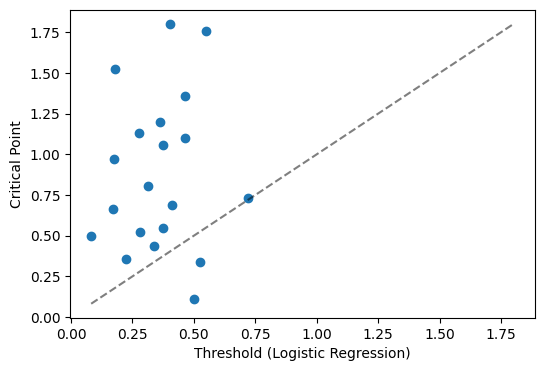

In [85]:
plt.figure(figsize=(6, 4))
plt.scatter(thresholds, metapoints)
min_plot = min(np.min(thresholds), np.min(metapoints))
max_plot = max(np.max(thresholds), np.max(metapoints))
plt.plot([min_plot, max_plot], [min_plot, max_plot], alpha=0.5, linestyle='--', color='black')
plt.xlabel('Threshold (Logistic Regression)')
plt.ylabel('Critical Point')
plt.show()

Participant 13: n_heard = 546, n_not_heard = 388
Metapoint           = 0.7297  (BA = 0.785)
Logistic (raw)      = 0.4925  (BA = 0.766)
Logistic (balanced) = 0.7220  (BA = 0.783)


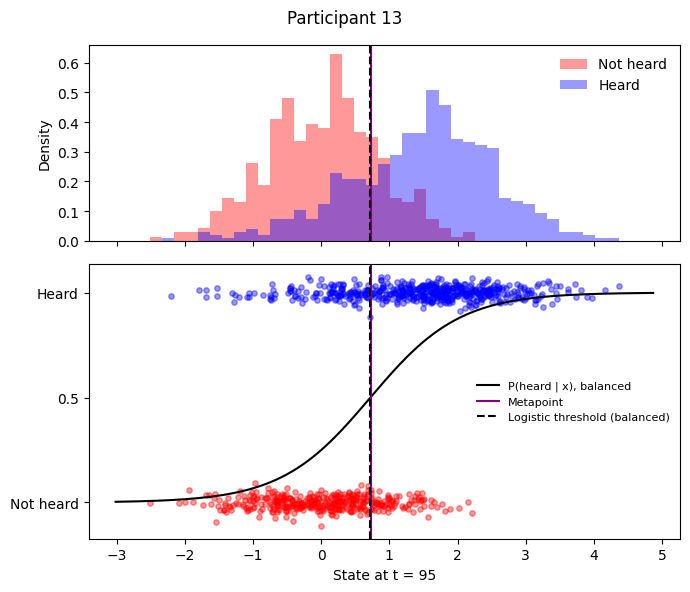

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score


def get_trial_data_at_time(time_idx, state_train, binaud, half_win=2):
    X, Y = [], []
    for cat in state_train.keys():
        for trial_idx, trial in enumerate(state_train[cat]):
            X.append(np.mean(trial[time_idx - half_win:time_idx + half_win + 1]))
            Y.append(binaud[cat][trial_idx])
    return np.array(X), np.array(Y).astype(int)


def logistic_threshold(X, Y, balanced=True):
    lr = LogisticRegression(penalty=None, class_weight='balanced' if balanced else None)
    lr.fit(X.reshape(-1, 1), Y)
    return -lr.intercept_[0] / lr.coef_[0, 0], lr


part = 13
time_idx = 95

metapoint, metascore = find_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
X, Y = get_trial_data_at_time(time_idx, trajectories_dict[part], binarized_audibilities_dict[part])

thr_lr, lr = logistic_threshold(X, Y, balanced=False)
thr_lr_bal, lr_bal = logistic_threshold(X, Y, balanced=True)

print(f"Participant {part}: n_heard = {Y.sum()}, n_not_heard = {(1 - Y).sum()}")
print(f"Metapoint           = {metapoint:.4f}  (BA = {balanced_accuracy_score(Y, X > metapoint):.3f})")
print(f"Logistic (raw)      = {thr_lr:.4f}  (BA = {balanced_accuracy_score(Y, X > thr_lr):.3f})")
print(f"Logistic (balanced) = {thr_lr_bal:.4f}  (BA = {balanced_accuracy_score(Y, X > thr_lr_bal):.3f})")

rng = np.random.default_rng(0)
xgrid = np.linspace(X.min() - 0.5, X.max() + 0.5, 400)
bins = np.linspace(X.min(), X.max(), 40)

fig, (ax_h, ax_s) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={'height_ratios': [1, 1.4]})

ax_h.hist(X[Y == 0], bins=bins, density=True, color='red', alpha=0.4, label='Not heard')
ax_h.hist(X[Y == 1], bins=bins, density=True, color='blue', alpha=0.4, label='Heard')
ax_h.set_ylabel('Density')
ax_h.legend(frameon=False)

ax_s.scatter(X[Y == 0], rng.normal(0, 0.03, (Y == 0).sum()), color='red', alpha=0.4, s=15)
ax_s.scatter(X[Y == 1], rng.normal(1, 0.03, (Y == 1).sum()), color='blue', alpha=0.4, s=15)
ax_s.plot(xgrid, lr_bal.predict_proba(xgrid.reshape(-1, 1))[:, 1], color='k', lw=1.5, label='P(heard | x), balanced')
ax_s.set_yticks([0, 0.5, 1])
ax_s.set_yticklabels(['Not heard', '0.5', 'Heard'])
ax_s.set_xlabel(f'State at t = {time_idx}')

lines = [(metapoint, 'purple', '-', 'Metapoint'),
         (thr_lr_bal, 'k', '--', 'Logistic threshold (balanced)')]
for ax in (ax_h, ax_s):
    for val, col, ls, lab in lines:
        ax.axvline(val, color=col, ls=ls, lw=1.5, label=lab if ax is ax_s else None)
ax_s.legend(frameon=False, loc='center right', fontsize=8)

fig.suptitle(f'Participant {part}')
fig.tight_layout()
plt.show()

 participant  metapoint  metascore  threshold    diff  ba_threshold  ba_metapoint  n_heard  n_not_heard
           0     0.5195     0.9997     0.2826 -0.2369        0.6113        0.6181      488          359
           1     1.1291     0.9960     0.2776 -0.8515        0.6445        0.5703      534          334
           2     1.0556     0.9947     0.3746 -0.6809        0.6165        0.6053      501          409
           3     0.4985     0.9779     0.0820 -0.4165        0.5417        0.5508      384          470
           4     0.9715     1.0000     0.1732 -0.7983        0.6260        0.6006      522          356
           5     0.3584     1.0000     0.2239 -0.1345        0.6136        0.6071      507          392
           6     0.3373     1.0000     0.5259  0.1885        0.6838        0.6768      313          577
           7     1.5215     0.8865     0.1795 -1.3420        0.6259        0.5383      607          265
           8     0.8068     1.0000     0.3130 -0.4938        0.6

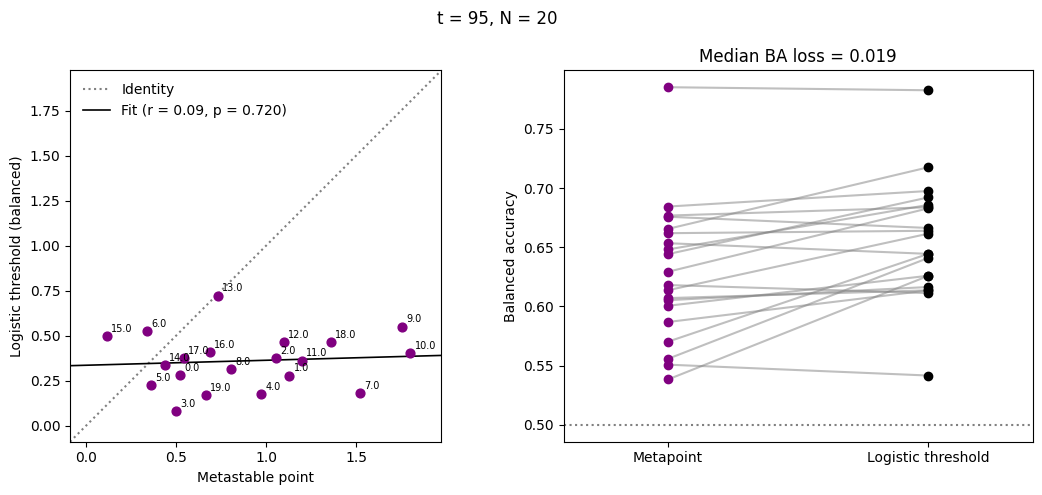

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score


def get_trial_data_at_time(time_idx, state_train, binaud, half_win=2):
    X, Y = [], []
    for cat in state_train.keys():
        for trial_idx, trial in enumerate(state_train[cat]):
            X.append(np.mean(trial[time_idx - half_win:time_idx + half_win + 1]))
            Y.append(binaud[cat][trial_idx])
    return np.array(X), np.array(Y).astype(int)


def logistic_threshold(X, Y, balanced=True):
    lr = LogisticRegression(penalty=None, class_weight='balanced' if balanced else None)
    lr.fit(X.reshape(-1, 1), Y)
    return -lr.intercept_[0] / lr.coef_[0, 0], lr


time_idx = 95
participants = sorted(models_dict.keys())

rows = []
for part in participants:
    metapoint, metascore = find_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
    X, Y = get_trial_data_at_time(time_idx, trajectories_dict[part], binarized_audibilities_dict[part])
    if Y.min() == Y.max():
        print(f"Participant {part}: only one class, skipped")
        continue
    thr, _ = logistic_threshold(X, Y, balanced=True)
    rows.append({
        'participant': part,
        'metapoint': metapoint,
        'metascore': metascore,
        'threshold': thr,
        'diff': thr - metapoint,
        'ba_threshold': balanced_accuracy_score(Y, X > thr),
        'ba_metapoint': balanced_accuracy_score(Y, X > metapoint),
        'n_heard': int(Y.sum()),
        'n_not_heard': int((1 - Y).sum()),
    })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

r, p_r = pearsonr(df['metapoint'], df['threshold'])
rho, p_rho = spearmanr(df['metapoint'], df['threshold'])
w_diff, p_diff = wilcoxon(df['diff'])
w_ba, p_ba = wilcoxon(df['ba_threshold'], df['ba_metapoint'])
print(f"\nPearson r = {r:.3f} (p = {p_r:.4f}); Spearman rho = {rho:.3f} (p = {p_rho:.4f})")
print(f"Threshold - metapoint: median = {df['diff'].median():.4f}, Wilcoxon p = {p_diff:.4f}")
print(f"BA optimal vs metapoint: median loss = {(df['ba_threshold'] - df['ba_metapoint']).median():.4f}, Wilcoxon p = {p_ba:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

lims = [min(df['metapoint'].min(), df['threshold'].min()), max(df['metapoint'].max(), df['threshold'].max())]
pad = 0.1 * (lims[1] - lims[0])
lims = [lims[0] - pad, lims[1] + pad]
slope, intercept = np.polyfit(df['metapoint'], df['threshold'], 1)
xfit = np.array(lims)

ax1.scatter(df['metapoint'], df['threshold'], color='purple', s=40, zorder=3)
for _, row in df.iterrows():
    ax1.annotate(str(row['participant']), (row['metapoint'], row['threshold']), fontsize=7,
                 xytext=(3, 3), textcoords='offset points')
ax1.plot(lims, lims, color='grey', ls=':', label='Identity')
ax1.plot(xfit, slope * xfit + intercept, color='k', lw=1.2, label=f'Fit (r = {r:.2f}, p = {p_r:.3f})')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_aspect('equal')
ax1.set_xlabel('Metastable point')
ax1.set_ylabel('Logistic threshold (balanced)')
ax1.legend(frameon=False)

for _, row in df.iterrows():
    ax2.plot([0, 1], [row['ba_metapoint'], row['ba_threshold']], color='grey', alpha=0.5)
ax2.scatter(np.zeros(len(df)), df['ba_metapoint'], color='purple', zorder=3, label='Metapoint')
ax2.scatter(np.ones(len(df)), df['ba_threshold'], color='k', zorder=3, label='Logistic threshold')
ax2.axhline(0.5, color='grey', ls=':')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Metapoint', 'Logistic threshold'])
ax2.set_xlim(-0.4, 1.4)
ax2.set_ylabel('Balanced accuracy')
ax2.set_title(f'Median BA loss = {(df["ba_threshold"] - df["ba_metapoint"]).median():.3f}')

fig.suptitle(f't = {time_idx}, N = {len(df)}')
fig.tight_layout()
plt.show()

# Testwith "low" and "high" critical points

In [71]:
def find_both_metapoint(gainmodul, n_categories):

    tau, process_noise, measure_noise, threshold = gainmodul.tau, gainmodul.process_noise, gainmodul.measure_noise, gainmodul.threshold

    states = np.linspace(-0.5, 3, 1000)
    delta_x_list = []
    max_metascore_low, best_metapoint_low = 0, None
    max_metascore_high, best_metapoint_high = 0, None
    
    for cat in range(n_categories - 1):
        # Initial state diff
        delta_x_list.append(gainmodul.core(state=states, input_value=1, signal_category=cat) - states)

        w1, g1 = getattr(gainmodul, f'w{cat}'), getattr(gainmodul, f'g{cat}')
        w2, g2 = getattr(gainmodul, f'w{cat+1}'), getattr(gainmodul, f'g{cat+1}')

        # Travel on the (w1, g1) -> (w2, g2) segment 
        for t in np.linspace(0, 1, 100):
            w, g = w1 + t*(w2-w1), g1 + t*(g2-g1)
            
            interp_model = lead.model.GainModulation(
                tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                threshold=threshold, sharpness=5, 
                input_weight=w, gain=g
            )

            # Prepare for metastability score calculation
            model_func = interp_model.core
            def f(states, input_value=0, signal_category=cat):
                return model_func(states, input_value * np.ones_like(states), signal_category) - states
            def df(states, input_value=0, signal_category=cat):
                epsilon = 1e-5
                return (f(states + epsilon, input_value, signal_category) - f(states - epsilon, input_value, signal_category)) / (2*epsilon)

            # Compute metastability score
            metapoint_low, metascore_low = metastability_score_point(lambda x: f(x, input_value=1, signal_category=cat), 
                                            lambda x: df(x, input_value=1, signal_category=cat), 
                                            states[states < threshold], tau=tau)
            if metascore_low > max_metascore_low:
                max_metascore_low = metascore_low
                best_metapoint_low = metapoint_low

            metapoint_high, metascore_high = metastability_score_point(lambda x: f(x, input_value=1, signal_category=cat), 
                                                lambda x: df(x, input_value=1, signal_category=cat), 
                                                states[states >= threshold], tau=tau)
            if metascore_high > max_metascore_high:
                max_metascore_high = metascore_high
                best_metapoint_high = metapoint_high

    return best_metapoint_low, best_metapoint_high

In [72]:
metapoints_low, metapoints_high, thresholds = [], [], []
for part in range(20):
    metapoint_low, metapoint_high = find_both_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
    metapoints_low.append(metapoint_low)
    metapoints_high.append(metapoint_high)

    X, Y = get_trial_data_at_time(100, trajectories_dict[part], binarized_audibilities_dict[part])
    log_reg = LogisticRegression(class_weight='balanced', penalty=None)
    log_reg.fit(X.reshape(-1, 1), Y)
    threshold = - log_reg.intercept_[0] / log_reg.coef_[0][0]
    thresholds.append(threshold)

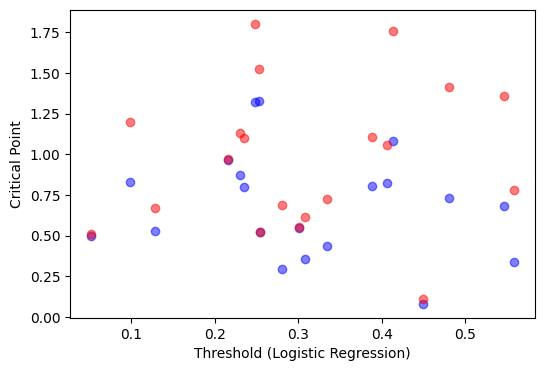

In [77]:
plt.figure(figsize=(6, 4))
plt.scatter(thresholds, metapoints_low, color='blue', alpha=0.5, label='Metapoint Low')
plt.scatter(thresholds, metapoints_high, color='red', alpha=0.5, label='Metapoint High')
plt.xlabel('Threshold (Logistic Regression)')
plt.ylabel('Critical Point')
plt.show()

Participant 13: n_heard = 546, n_not_heard = 388
Metapoint low       = 0.7297  (BA = 0.785)
Metapoint high      = 1.4129  (BA = 0.764)
Logistic (balanced) = 0.7220  (BA = 0.783)


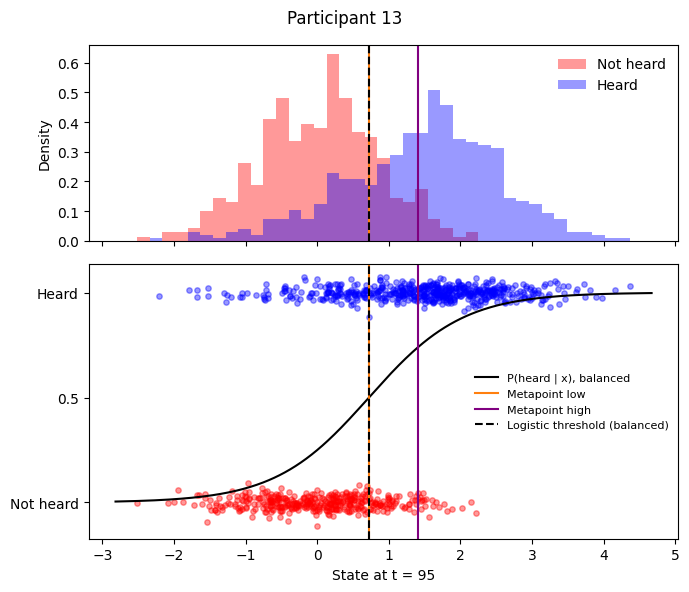

 participant  mp_low  mp_high  threshold  diff_low  diff_high  absdist_low  absdist_high  ba_threshold  ba_low  ba_high  n_heard  n_not_heard
           0  0.5195   0.5230     0.2826   -0.2369    -0.2404       0.2369        0.2404        0.6113  0.6181   0.6195      488          359
           1  0.8699   1.1291     0.2776   -0.5923    -0.8515       0.5923        0.8515        0.6445  0.6016   0.5703      534          334
           2  0.8243   1.0556     0.3746   -0.4497    -0.6809       0.4497        0.6809        0.6165  0.6219   0.6053      501          409
           3  0.4985   0.5125     0.0820   -0.4165    -0.4305       0.4165        0.4305        0.5417  0.5508   0.5530      384          470
           4  0.9645   0.9715     0.1732   -0.7913    -0.7983       0.7913        0.7983        0.6260  0.6025   0.6006      522          356
           5  0.3584   0.6141     0.2239   -0.1345    -0.3902       0.1345        0.3902        0.6136  0.6071   0.6001      507          392
      

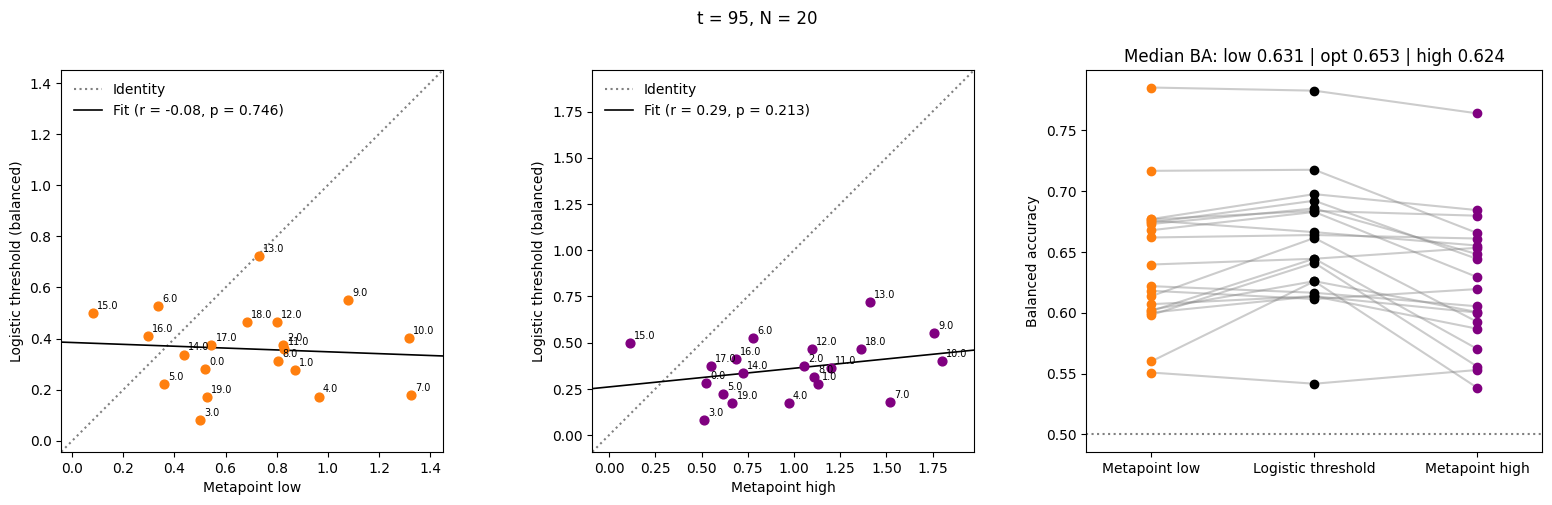

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score


def get_trial_data_at_time(time_idx, state_train, binaud, half_win=2):
    X, Y = [], []
    for cat in state_train.keys():
        for trial_idx, trial in enumerate(state_train[cat]):
            X.append(np.mean(trial[time_idx - half_win:time_idx + half_win + 1]))
            Y.append(binaud[cat][trial_idx])
    return np.array(X), np.array(Y).astype(int)


def logistic_threshold(X, Y, balanced=True):
    lr = LogisticRegression(penalty=None, class_weight='balanced' if balanced else None)
    lr.fit(X.reshape(-1, 1), Y)
    return -lr.intercept_[0] / lr.coef_[0, 0], lr


time_idx = 95
colors = {'low': 'tab:orange', 'high': 'purple', 'thr': 'k'}


# ---------- Single participant ----------
part = 13

mp_low, mp_high = find_both_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
X, Y = get_trial_data_at_time(time_idx, trajectories_dict[part], binarized_audibilities_dict[part])
thr, lr_bal = logistic_threshold(X, Y, balanced=True)

print(f"Participant {part}: n_heard = {Y.sum()}, n_not_heard = {(1 - Y).sum()}")
print(f"Metapoint low       = {mp_low:.4f}  (BA = {balanced_accuracy_score(Y, X > mp_low):.3f})")
print(f"Metapoint high      = {mp_high:.4f}  (BA = {balanced_accuracy_score(Y, X > mp_high):.3f})")
print(f"Logistic (balanced) = {thr:.4f}  (BA = {balanced_accuracy_score(Y, X > thr):.3f})")

rng = np.random.default_rng(0)
xgrid = np.linspace(min(X.min(), mp_low, mp_high) - 0.3, max(X.max(), mp_low, mp_high) + 0.3, 400)
bins = np.linspace(X.min(), X.max(), 40)

fig, (ax_h, ax_s) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={'height_ratios': [1, 1.4]})
ax_h.hist(X[Y == 0], bins=bins, density=True, color='red', alpha=0.4, label='Not heard')
ax_h.hist(X[Y == 1], bins=bins, density=True, color='blue', alpha=0.4, label='Heard')
ax_h.set_ylabel('Density')
ax_h.legend(frameon=False)

ax_s.scatter(X[Y == 0], rng.normal(0, 0.03, (Y == 0).sum()), color='red', alpha=0.4, s=15)
ax_s.scatter(X[Y == 1], rng.normal(1, 0.03, (Y == 1).sum()), color='blue', alpha=0.4, s=15)
ax_s.plot(xgrid, lr_bal.predict_proba(xgrid.reshape(-1, 1))[:, 1], color='k', lw=1.5, label='P(heard | x), balanced')
ax_s.set_yticks([0, 0.5, 1])
ax_s.set_yticklabels(['Not heard', '0.5', 'Heard'])
ax_s.set_xlabel(f'State at t = {time_idx}')

lines = [(mp_low, colors['low'], '-', 'Metapoint low'),
         (mp_high, colors['high'], '-', 'Metapoint high'),
         (thr, colors['thr'], '--', 'Logistic threshold (balanced)')]
for ax in (ax_h, ax_s):
    for val, col, ls, lab in lines:
        ax.axvline(val, color=col, ls=ls, lw=1.5, label=lab if ax is ax_s else None)
ax_s.legend(frameon=False, loc='center right', fontsize=8)
fig.suptitle(f'Participant {part}')
fig.tight_layout()
plt.show()


# ---------- All participants ----------
participants = sorted(models_dict.keys())
rows = []
for part in participants:
    mp_low, mp_high = find_both_metapoint(models_dict[part], n_categories=len(trajectories_dict[part]))
    if mp_low is None or mp_high is None:
        print(f"Participant {part}: missing metapoint (low={mp_low}, high={mp_high}), skipped")
        continue
    X, Y = get_trial_data_at_time(time_idx, trajectories_dict[part], binarized_audibilities_dict[part])
    if Y.min() == Y.max():
        print(f"Participant {part}: only one class, skipped")
        continue
    thr, _ = logistic_threshold(X, Y, balanced=True)
    rows.append({
        'participant': part,
        'mp_low': mp_low,
        'mp_high': mp_high,
        'threshold': thr,
        'diff_low': thr - mp_low,
        'diff_high': thr - mp_high,
        'absdist_low': abs(thr - mp_low),
        'absdist_high': abs(thr - mp_high),
        'ba_threshold': balanced_accuracy_score(Y, X > thr),
        'ba_low': balanced_accuracy_score(Y, X > mp_low),
        'ba_high': balanced_accuracy_score(Y, X > mp_high),
        'n_heard': int(Y.sum()),
        'n_not_heard': int((1 - Y).sum()),
    })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

stats = {}
for key in ['low', 'high']:
    r, p_r = pearsonr(df[f'mp_{key}'], df['threshold'])
    rho, p_rho = spearmanr(df[f'mp_{key}'], df['threshold'])
    _, p_diff = wilcoxon(df[f'diff_{key}'])
    _, p_ba = wilcoxon(df['ba_threshold'], df[f'ba_{key}'])
    stats[key] = dict(r=r, p_r=p_r)
    print(f"\n[{key.upper()}] Pearson r = {r:.3f} (p = {p_r:.4f}); Spearman rho = {rho:.3f} (p = {p_rho:.4f})")
    print(f"[{key.upper()}] Threshold - metapoint: median = {df[f'diff_{key}'].median():.4f}, Wilcoxon p = {p_diff:.4f}")
    print(f"[{key.upper()}] BA loss vs optimal: median = {(df['ba_threshold'] - df[f'ba_{key}']).median():.4f}, Wilcoxon p = {p_ba:.4f}")

_, p_dist = wilcoxon(df['absdist_low'], df['absdist_high'])
_, p_ba_lh = wilcoxon(df['ba_low'], df['ba_high'])
print(f"\n|thr - low| vs |thr - high|: medians = {df['absdist_low'].median():.4f} vs {df['absdist_high'].median():.4f}, Wilcoxon p = {p_dist:.4f}")
print(f"Closer to low in {(df['absdist_low'] < df['absdist_high']).sum()}/{len(df)} participants")
print(f"BA low vs high: medians = {df['ba_low'].median():.4f} vs {df['ba_high'].median():.4f}, Wilcoxon p = {p_ba_lh:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, key, label in [(axes[0], 'low', 'Metapoint low'), (axes[1], 'high', 'Metapoint high')]:
    xs, ys = df[f'mp_{key}'], df['threshold']
    lo, hi = min(xs.min(), ys.min()), max(xs.max(), ys.max())
    pad = 0.1 * (hi - lo)
    lims = [lo - pad, hi + pad]
    slope, intercept = np.polyfit(xs, ys, 1)
    ax.scatter(xs, ys, color=colors[key], s=40, zorder=3)
    for _, row in df.iterrows():
        ax.annotate(str(row['participant']), (row[f'mp_{key}'], row['threshold']), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.plot(lims, lims, color='grey', ls=':', label='Identity')
    ax.plot(lims, slope * np.array(lims) + intercept, color='k', lw=1.2,
            label=f"Fit (r = {stats[key]['r']:.2f}, p = {stats[key]['p_r']:.3f})")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_xlabel(label)
    ax.set_ylabel('Logistic threshold (balanced)')
    ax.legend(frameon=False)

ax = axes[2]
for _, row in df.iterrows():
    ax.plot([0, 1, 2], [row['ba_low'], row['ba_threshold'], row['ba_high']], color='grey', alpha=0.4)
ax.scatter(np.zeros(len(df)), df['ba_low'], color=colors['low'], zorder=3)
ax.scatter(np.ones(len(df)), df['ba_threshold'], color=colors['thr'], zorder=3)
ax.scatter(2 * np.ones(len(df)), df['ba_high'], color=colors['high'], zorder=3)
ax.axhline(0.5, color='grey', ls=':')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Metapoint low', 'Logistic threshold', 'Metapoint high'])
ax.set_xlim(-0.4, 2.4)
ax.set_ylabel('Balanced accuracy')
ax.set_title(f"Median BA: low {df['ba_low'].median():.3f} | opt {df['ba_threshold'].median():.3f} | high {df['ba_high'].median():.3f}")

fig.suptitle(f't = {time_idx}, N = {len(df)}')
fig.tight_layout()
plt.show()

Participant 0 done
Participant 1 done
Participant 2 done
Participant 3 done
Participant 4 done
Participant 5 done
Participant 6 done
Participant 7 done
Participant 8 done
Participant 9 done
Participant 10 done
Participant 11 done
Participant 12 done
Participant 13 done
Participant 14 done
Participant 15 done
Participant 16 done
Participant 17 done
Participant 18 done
Participant 19 done


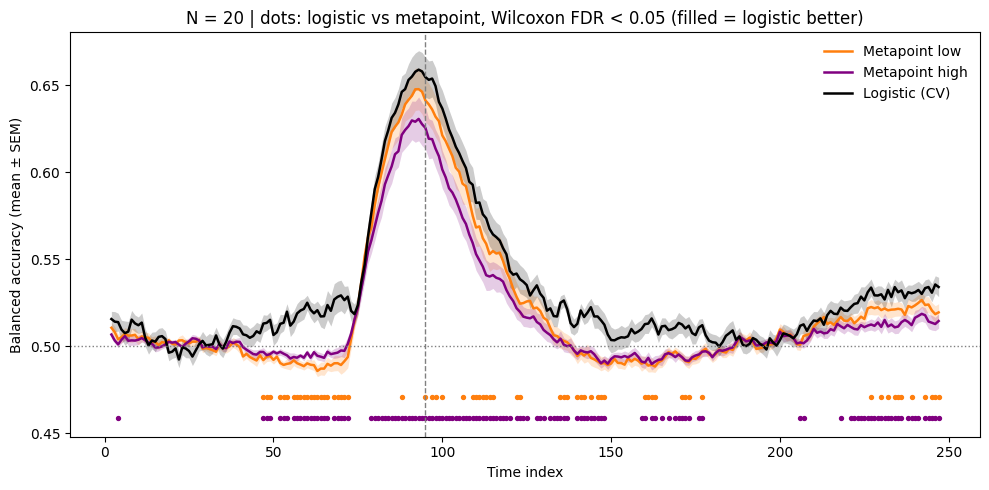

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

half_win = 2
cv = True
n_splits = 5
alpha = 0.05
mark_time = 95


def get_trial_data_at_time(time_idx, state_train, binaud, half_win=2):
    X, Y = [], []
    for cat in state_train.keys():
        for trial_idx, trial in enumerate(state_train[cat]):
            X.append(np.mean(trial[time_idx - half_win:time_idx + half_win + 1]))
            Y.append(binaud[cat][trial_idx])
    return np.array(X), np.array(Y).astype(int)


def fit_logistic(X, Y):
    lr = LogisticRegression(penalty=None, class_weight='balanced')
    lr.fit(X.reshape(-1, 1), Y)
    return lr


def logistic_threshold(X, Y):
    lr = fit_logistic(X, Y)
    return -lr.intercept_[0] / lr.coef_[0, 0]


def ba_logistic(X, Y, cv=True, n_splits=5, seed=0):
    if not cv:
        return balanced_accuracy_score(Y, fit_logistic(X, Y).predict(X.reshape(-1, 1)))
    y_pred = np.zeros_like(Y)
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, Y):
        y_pred[te] = fit_logistic(X[tr], Y[tr]).predict(X[te].reshape(-1, 1))
    return balanced_accuracy_score(Y, y_pred)


def bh_fdr(p):
    p = np.asarray(p)
    n = len(p)
    order = np.argsort(p)
    q = p[order] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out


def safe_wilcoxon(a, b):
    try:
        return wilcoxon(a, b).pvalue
    except ValueError:
        return 1.0


participants = sorted(models_dict.keys())
metapoints = {}
for p in participants:
    lo, hi = find_both_metapoint(models_dict[p], n_categories=len(trajectories_dict[p]))
    if lo is None or hi is None:
        print(f"Participant {p}: missing metapoint (low={lo}, high={hi}), skipped")
        continue
    metapoints[p] = (lo, hi)
parts = list(metapoints)

n_t = min(len(next(iter(trajectories_dict[p].values()))[0]) for p in parts)
times = np.arange(half_win, n_t - half_win)

ba = {k: np.full((len(parts), len(times)), np.nan) for k in ['low', 'high', 'logistic']}
for i, p in enumerate(parts):
    lo, hi = metapoints[p]
    for j, t in enumerate(times):
        X, Y = get_trial_data_at_time(t, trajectories_dict[p], binarized_audibilities_dict[p], half_win)
        if Y.min() == Y.max():
            continue
        ba['low'][i, j] = balanced_accuracy_score(Y, X > lo)
        ba['high'][i, j] = balanced_accuracy_score(Y, X > hi)
        ba['logistic'][i, j] = ba_logistic(X, Y, cv=cv, n_splits=n_splits)
    print(f"Participant {p} done")

sig, better_logistic = {}, {}
for k in ['low', 'high']:
    pvals = np.array([safe_wilcoxon(ba['logistic'][:, j], ba[k][:, j]) for j in range(len(times))])
    sig[k] = bh_fdr(pvals) < alpha
    better_logistic[k] = np.nanmedian(ba['logistic'] - ba[k], axis=0) > 0

colors = {'low': 'tab:orange', 'high': 'purple', 'logistic': 'k'}
labels = {'low': 'Metapoint low', 'high': 'Metapoint high', 'logistic': f"Logistic ({'CV' if cv else 'in-sample'})"}

fig, ax = plt.subplots(figsize=(10, 5))
lows = []
for k in ['low', 'high', 'logistic']:
    m = np.nanmean(ba[k], axis=0)
    se = np.nanstd(ba[k], axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(ba[k]), axis=0))
    ax.plot(times, m, color=colors[k], lw=1.8, label=labels[k])
    ax.fill_between(times, m - se, m + se, color=colors[k], alpha=0.2, lw=0)
    lows.append(np.nanmin(m - se))

base = min(lows)
for offset, k in zip([0.012, 0.024], ['low', 'high']):
    y = base - offset
    fill = sig[k] & better_logistic[k]
    hollow = sig[k] & ~better_logistic[k]
    ax.scatter(times[fill], np.full(fill.sum(), y), s=8, color=colors[k])
    ax.scatter(times[hollow], np.full(hollow.sum(), y), s=8, facecolors='none', edgecolors=colors[k])

ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.axvline(mark_time, color='grey', ls='--', lw=1)
ax.set_xlabel('Time index')
ax.set_ylabel('Balanced accuracy (mean ± SEM)')
ax.set_title(f'N = {len(parts)} | dots: logistic vs metapoint, Wilcoxon FDR < {alpha} (filled = logistic better)')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

[LOW] Median BA loss: observed = 0.0099 | shuffled median = 0.0088 [0.0019, 0.0163] | group-median point = 0.0077 | p(own < shuffled) = 0.5931
[LOW] Median |threshold - metapoint|: observed = 0.3860 | shuffled median = 0.3404 [0.2476, 0.4319] | group-median point = 0.3398 | p(own < shuffled) = 0.8386
[HIGH] Median BA loss: observed = 0.0220 | shuffled median = 0.0216 [0.0114, 0.0338] | group-median point = 0.0269 | p(own < shuffled) = 0.5210
[HIGH] Median |threshold - metapoint|: observed = 0.6566 | shuffled median = 0.6012 [0.4856, 0.7138] | group-median point = 0.6463 | p(own < shuffled) = 0.8429


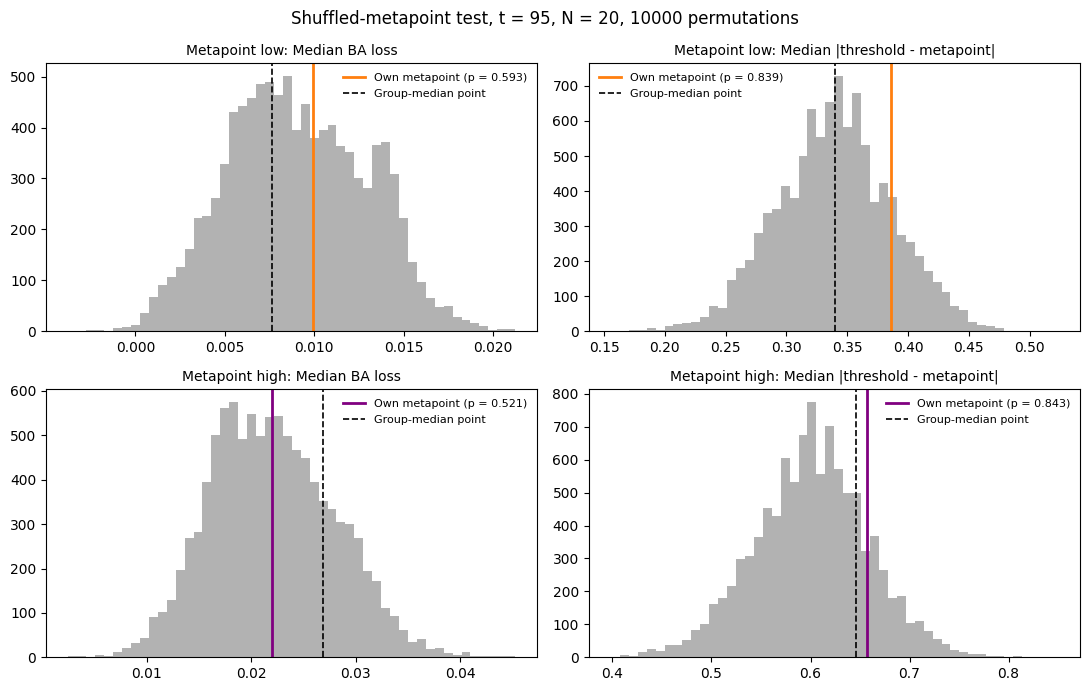

In [92]:
time_idx = 95
n_perm = 10000
rng = np.random.default_rng(0)

parts = list(metapoints)
n = len(parts)
mp = {'low': np.array([metapoints[p][0] for p in parts]),
      'high': np.array([metapoints[p][1] for p in parts])}
data = {p: get_trial_data_at_time(time_idx, trajectories_dict[p], binarized_audibilities_dict[p], half_win) for p in parts}
thr = np.array([logistic_threshold(*data[p]) for p in parts])
ba_thr = np.array([balanced_accuracy_score(data[p][1], data[p][0] > thr[i]) for i, p in enumerate(parts)])

perms = np.array([rng.permutation(n) for _ in range(n_perm)])
rows_idx = np.arange(n)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for r, key in enumerate(['low', 'high']):
    pts = mp[key]
    loss_mat = np.array([[ba_thr[i] - balanced_accuracy_score(data[p][1], data[p][0] > pts[k]) for k in range(n)]
                         for i, p in enumerate(parts)])
    dist_mat = np.abs(thr[:, None] - pts[None, :])
    group_pt = np.median(pts)

    for c, (name, mat, const_vals) in enumerate([
        ('Median BA loss', loss_mat,
         np.array([ba_thr[i] - balanced_accuracy_score(data[p][1], data[p][0] > group_pt) for i, p in enumerate(parts)])),
        ('Median |threshold - metapoint|', dist_mat, np.abs(thr - group_pt)),
    ]):
        obs = np.median(mat[rows_idx, rows_idx])
        null = np.median(mat[rows_idx[None, :], perms], axis=1)
        const = np.median(const_vals)
        p_perm = (np.sum(null <= obs) + 1) / (n_perm + 1)
        print(f"[{key.upper()}] {name}: observed = {obs:.4f} | shuffled median = {np.median(null):.4f} "
              f"[{np.percentile(null, 2.5):.4f}, {np.percentile(null, 97.5):.4f}] | "
              f"group-median point = {const:.4f} | p(own < shuffled) = {p_perm:.4f}")

        ax = axes[r, c]
        ax.hist(null, bins=50, color='grey', alpha=0.6)
        ax.axvline(obs, color=colors[key], lw=2, label=f'Own metapoint (p = {p_perm:.3f})')
        ax.axvline(const, color='k', ls='--', lw=1.2, label='Group-median point')
        ax.set_title(f'{labels[key]}: {name}', fontsize=10)
        ax.legend(frameon=False, fontsize=8)

fig.suptitle(f'Shuffled-metapoint test, t = {time_idx}, N = {n}, {n_perm} permutations')
fig.tight_layout()
plt.show()

 participant  mp_low  mp_high  threshold  grid_min  grid_max  at_edge  diff_low  diff_high  ba_opt_in  ba_opt_cv  ba_low  ba_high  heard_rate_true  heard_rate_opt
           0  0.5195   0.5230     0.4237   -0.9084    1.3939    False   -0.0958    -0.0994     0.6263     0.6157  0.6163   0.6153           0.5762          0.4770
           1  0.8699   1.1291     0.2009   -0.8303    1.4439    False   -0.6690    -0.9282     0.6288     0.6020  0.6169   0.5785           0.6152          0.5507
           2  0.8243   1.0556     0.2749   -0.7846    1.4770    False   -0.5495    -0.7807     0.6421     0.6351  0.6211   0.5939           0.5505          0.5549
           3  0.4985   0.5125    -0.0912   -1.0328    1.1296    False   -0.5897    -0.6038     0.5718     0.5521  0.5482   0.5498           0.4496          0.5199
           4  0.9645   0.9715     0.4308   -0.8952    1.3808    False   -0.5337    -0.5407     0.6482     0.6349  0.5975   0.5966           0.5945          0.4066
           5  0.3584  

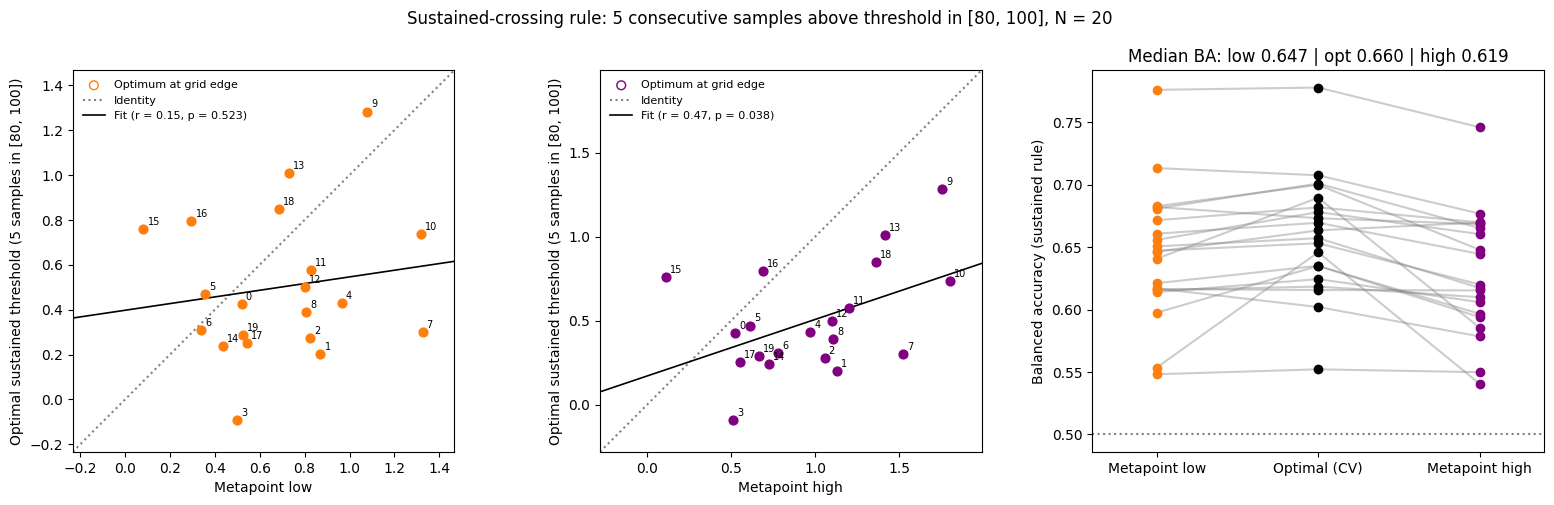

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import pearsonr, spearmanr, wilcoxon
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

t_start, t_end = 80, 100
min_run = 5
n_thr = 1000
n_splits = 5
n_perm = 10000
rng = np.random.default_rng(0)
colors = {'low': 'tab:orange', 'high': 'purple', 'opt': 'k'}


def sustained_peak(state_train, binaud, t_start, t_end, min_run):
    S, Y, W = [], [], []
    for cat in state_train.keys():
        for trial_idx, trial in enumerate(state_train[cat]):
            seg = np.asarray(trial[t_start:t_end + 1])
            S.append(sliding_window_view(seg, min_run).min(axis=1).max())
            Y.append(binaud[cat][trial_idx])
            W.append(seg)
    return np.array(S), np.array(Y).astype(int), np.concatenate(W)


def ba_curve(S, Y, grid):
    pred = S[None, :] > np.asarray(grid)[:, None]
    tpr = pred[:, Y == 1].mean(axis=1)
    tnr = (~pred[:, Y == 0]).mean(axis=1)
    return 0.5 * (tpr + tnr)


def ba_rule(S, Y, th):
    return ba_curve(S, Y, [th])[0]


def best_threshold(S, Y, grid):
    ba = ba_curve(S, Y, grid)
    idx = np.flatnonzero(ba == ba.max())
    k = idx[len(idx) // 2]
    return grid[k], ba[k], k


def ba_cv(S, Y, grid, n_splits=5, seed=0):
    pred = np.zeros_like(Y)
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(S, Y):
        th, _, _ = best_threshold(S[tr], Y[tr], grid)
        pred[te] = S[te] > th
    return balanced_accuracy_score(Y, pred)


if 'metapoints' not in globals():
    metapoints = {}
    for p in sorted(models_dict.keys()):
        lo, hi = find_both_metapoint(models_dict[p], n_categories=len(trajectories_dict[p]))
        if lo is None or hi is None:
            print(f"Participant {p}: missing metapoint (low={lo}, high={hi}), skipped")
            continue
        metapoints[p] = (lo, hi)

rows, data = [], {}
for p, (lo, hi) in metapoints.items():
    S, Y, W = sustained_peak(trajectories_dict[p], binarized_audibilities_dict[p], t_start, t_end, min_run)
    if Y.min() == Y.max():
        print(f"Participant {p}: only one class, skipped")
        continue
    grid = np.linspace(W.mean() - W.std(), W.mean() + W.std(), n_thr)
    thr, ba_in, k = best_threshold(S, Y, grid)
    data[p] = (S, Y)
    rows.append({
        'participant': p,
        'mp_low': lo,
        'mp_high': hi,
        'threshold': thr,
        'grid_min': grid[0],
        'grid_max': grid[-1],
        'at_edge': k in (0, n_thr - 1),
        'diff_low': thr - lo,
        'diff_high': thr - hi,
        'ba_opt_in': ba_in,
        'ba_opt_cv': ba_cv(S, Y, grid, n_splits),
        'ba_low': ba_rule(S, Y, lo),
        'ba_high': ba_rule(S, Y, hi),
        'heard_rate_true': Y.mean(),
        'heard_rate_opt': (S > thr).mean(),
    })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))
if df['at_edge'].any():
    print(f"\nWARNING: optimum on grid edge for participants {df.loc[df['at_edge'], 'participant'].tolist()}")

stats = {}
for key in ['low', 'high']:
    r, p_r = pearsonr(df[f'mp_{key}'], df['threshold'])
    rho, p_rho = spearmanr(df[f'mp_{key}'], df['threshold'])
    _, p_diff = wilcoxon(df[f'diff_{key}'])
    _, p_ba = wilcoxon(df['ba_opt_cv'], df[f'ba_{key}'])
    stats[key] = dict(r=r, p_r=p_r)
    print(f"\n[{key.upper()}] Pearson r = {r:.3f} (p = {p_r:.4f}); Spearman rho = {rho:.3f} (p = {p_rho:.4f})")
    print(f"[{key.upper()}] Threshold - metapoint: median = {df[f'diff_{key}'].median():.4f}, Wilcoxon p = {p_diff:.4f}")
    print(f"[{key.upper()}] BA optimal(CV) - metapoint: median = {(df['ba_opt_cv'] - df[f'ba_{key}']).median():.4f}, Wilcoxon p = {p_ba:.4f}")

_, p_dist = wilcoxon(np.abs(df['diff_low']), np.abs(df['diff_high']))
_, p_ba_lh = wilcoxon(df['ba_low'], df['ba_high'])
print(f"\n|thr - low| vs |thr - high|: medians = {np.abs(df['diff_low']).median():.4f} vs {np.abs(df['diff_high']).median():.4f}, Wilcoxon p = {p_dist:.4f}")
print(f"Threshold below low: {(df['diff_low'] < 0).sum()}/{len(df)} | between low and high: "
      f"{((df['diff_low'] >= 0) & (df['diff_high'] <= 0)).sum()}/{len(df)} | above high: {(df['diff_high'] > 0).sum()}/{len(df)}")
print(f"BA low vs high: medians = {df['ba_low'].median():.4f} vs {df['ba_high'].median():.4f}, Wilcoxon p = {p_ba_lh:.4f}")

parts = df['participant'].tolist()
n = len(parts)
thr_arr = df['threshold'].to_numpy()
ba_ref = df['ba_opt_cv'].to_numpy()
perms = np.array([rng.permutation(n) for _ in range(n_perm)])
ii = np.arange(n)
print()
for key in ['low', 'high']:
    pts = df[f'mp_{key}'].to_numpy()
    loss_mat = np.array([[ba_ref[i] - ba_rule(*data[p], pts[k]) for k in range(n)] for i, p in enumerate(parts)])
    dist_mat = np.abs(thr_arr[:, None] - pts[None, :])
    for name, mat in [('Median BA loss', loss_mat), ('Median |threshold - metapoint|', dist_mat)]:
        obs = np.median(mat[ii, ii])
        null = np.median(mat[ii[None, :], perms], axis=1)
        p_perm = (np.sum(null <= obs) + 1) / (n_perm + 1)
        print(f"[{key.upper()} shuffle] {name}: observed = {obs:.4f} | shuffled median = {np.median(null):.4f} "
              f"[{np.percentile(null, 2.5):.4f}, {np.percentile(null, 97.5):.4f}] | p(own < shuffled) = {p_perm:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key, label in [(axes[0], 'low', 'Metapoint low'), (axes[1], 'high', 'Metapoint high')]:
    xs, ys = df[f'mp_{key}'], df['threshold']
    lo, hi = min(xs.min(), ys.min()), max(xs.max(), ys.max())
    pad = 0.1 * (hi - lo)
    lims = [lo - pad, hi + pad]
    slope, intercept = np.polyfit(xs, ys, 1)
    ax.scatter(xs[~df['at_edge']], ys[~df['at_edge']], color=colors[key], s=40, zorder=3)
    ax.scatter(xs[df['at_edge']], ys[df['at_edge']], facecolors='none', edgecolors=colors[key], s=40, zorder=3, label='Optimum at grid edge')
    for _, row in df.iterrows():
        ax.annotate(str(row['participant']), (row[f'mp_{key}'], row['threshold']), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.plot(lims, lims, color='grey', ls=':', label='Identity')
    ax.plot(lims, slope * np.array(lims) + intercept, color='k', lw=1.2,
            label=f"Fit (r = {stats[key]['r']:.2f}, p = {stats[key]['p_r']:.3f})")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_xlabel(label)
    ax.set_ylabel(f'Optimal sustained threshold ({min_run} samples in [{t_start}, {t_end}])')
    ax.legend(frameon=False, fontsize=8)

ax = axes[2]
for _, row in df.iterrows():
    ax.plot([0, 1, 2], [row['ba_low'], row['ba_opt_cv'], row['ba_high']], color='grey', alpha=0.4)
ax.scatter(np.zeros(n), df['ba_low'], color=colors['low'], zorder=3)
ax.scatter(np.ones(n), df['ba_opt_cv'], color=colors['opt'], zorder=3)
ax.scatter(2 * np.ones(n), df['ba_high'], color=colors['high'], zorder=3)
ax.axhline(0.5, color='grey', ls=':')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Metapoint low', 'Optimal (CV)', 'Metapoint high'])
ax.set_xlim(-0.4, 2.4)
ax.set_ylabel('Balanced accuracy (sustained rule)')
ax.set_title(f"Median BA: low {df['ba_low'].median():.3f} | opt {df['ba_opt_cv'].median():.3f} | high {df['ba_high'].median():.3f}")

fig.suptitle(f'Sustained-crossing rule: {min_run} consecutive samples above threshold in [{t_start}, {t_end}], N = {n}')
fig.tight_layout()
plt.show()